# Bonds and Economic Indicators

This notebook covers two related pieces of macro data:

- **US Treasury yield curve** — 3-month, 5-year, 10-year, and 30-year yields (Yahoo Finance tickers `^IRX`, `^FVX`, `^TNX`, `^TYX`), including the 10Y–3M spread, the New York Fed's preferred yield-curve recession indicator.
- **Economic indicators, US vs. Thailand** — GDP, inflation, unemployment, government debt, and current account balance, all from World Bank, so both countries use directly comparable definitions.

Everything here comes from keyless sources (Yahoo Finance, World Bank) and runs out of the box. The catalog also has FRED series (`us_cpi`, `fed_funds_rate`) that would round this out with the Fed funds rate and US CPI — those need `FRED_API_KEY` in `.env`; this notebook attempts them and shows what happens either way.

Sections:
1. US Treasury yield curve — current snapshot and historical moves
2. Curve inversion — the 10Y–3M spread as a recession signal
3. Economic indicators — US vs. Thailand
4. FRED series (optional, needs API key)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from macro_data import update, load

pd.set_option("display.max_rows", 20)
%matplotlib inline

update("yahoo")
update("worldbank")

us_3m = load("us_3m_yield")
us_5y = load("us_5y_yield")
us_10y = load("us_10y_yield")
us_30y = load("us_30y_yield")

## 1. US Treasury yield curve

The **yield curve** plots yield against maturity at a point in time. Normally it slopes upward (longer maturities pay more, compensating for locking up money longer). When it inverts — short maturities yield more than long ones — that's historically preceded most US recessions.

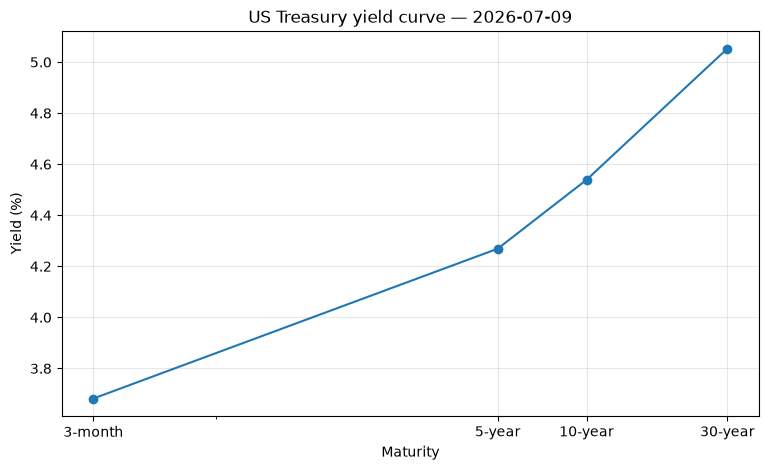

3-month    3.682
5-year     4.269
10-year    4.539
30-year    5.053
dtype: float64

In [2]:
maturities_years = {"3-month": 0.25, "5-year": 5, "10-year": 10, "30-year": 30}
yields = {"3-month": us_3m, "5-year": us_5y, "10-year": us_10y, "30-year": us_30y}
latest_date = min(df.index.max() for df in yields.values())

curve = pd.Series(
    {label: df.loc[:latest_date, "value"].iloc[-1] for label, df in yields.items()}
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(maturities_years.values()), curve[list(maturities_years.keys())], marker="o")
ax.set_xscale("symlog")
ax.set_xticks(list(maturities_years.values()))
ax.set_xticklabels(list(maturities_years.keys()))
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield (%)")
ax.set_title(f"US Treasury yield curve — {latest_date.date()}")
ax.grid(alpha=0.3)
plt.show()

curve

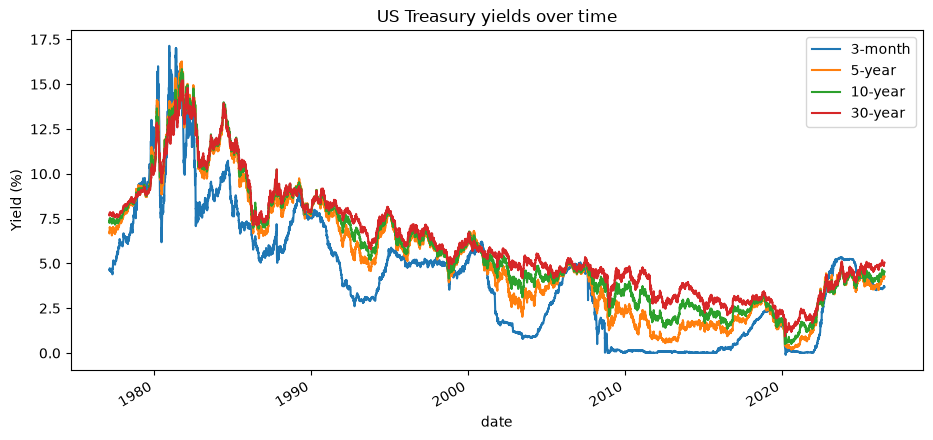

In [3]:
history = pd.DataFrame({label: df["value"] for label, df in yields.items()}).dropna()

fig, ax = plt.subplots(figsize=(11, 5))
history.plot(ax=ax, title="US Treasury yields over time")
ax.set_ylabel("Yield (%)")
plt.show()

## 2. Curve inversion: the 10Y–3M spread

The New York Fed's recession-probability model uses the **10-year minus 3-month** spread specifically (rather than 10Y–2Y) because it has the strongest historical track record. A negative spread means the curve is inverted.

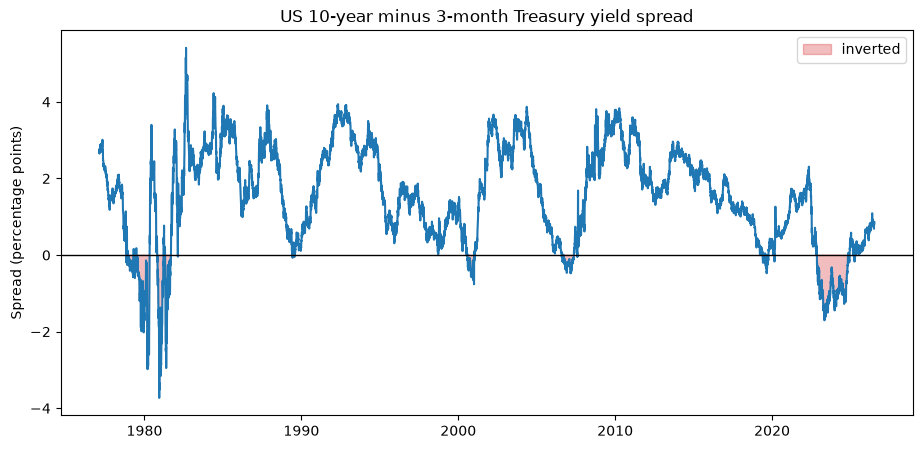

Current spread: 0.86 pp
Days inverted in this window: 1474 / 12373 (11.9%)


In [4]:
spread = (history["10-year"] - history["3-month"]).rename("value").to_frame()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(spread.index, spread["value"])
ax.axhline(0, color="black", linewidth=1)
ax.fill_between(spread.index, spread["value"], 0, where=spread["value"] < 0, color="tab:red", alpha=0.3, label="inverted")
ax.set_title("US 10-year minus 3-month Treasury yield spread")
ax.set_ylabel("Spread (percentage points)")
ax.legend()
plt.show()

inverted_days = (spread["value"] < 0).sum()
print(f"Current spread: {spread['value'].iloc[-1]:.2f} pp")
print(f"Days inverted in this window: {inverted_days} / {len(spread)} ({inverted_days / len(spread) * 100:.1f}%)")

## 3. Economic indicators: US vs. Thailand

World Bank indicators are annual and use the same methodology across countries, so US and Thailand are directly comparable. GDP is plotted on separate axes (very different scales); the rest share a percentage scale.

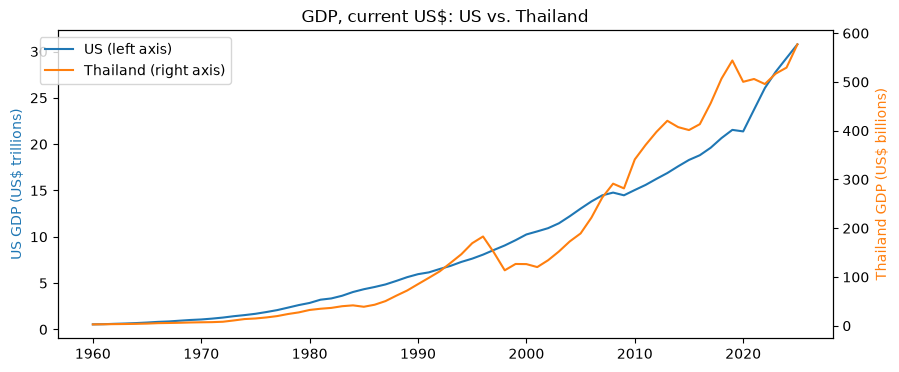

In [5]:
us_gdp = load("us_gdp_usd")
th_gdp = load("th_gdp_usd")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(us_gdp.index, us_gdp["value"] / 1e12, color="tab:blue", label="US (left axis)")
ax2.plot(th_gdp.index, th_gdp["value"] / 1e9, color="tab:orange", label="Thailand (right axis)")
ax1.set_ylabel("US GDP (US$ trillions)", color="tab:blue")
ax2.set_ylabel("Thailand GDP (US$ billions)", color="tab:orange")
ax1.set_title("GDP, current US$: US vs. Thailand")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.show()

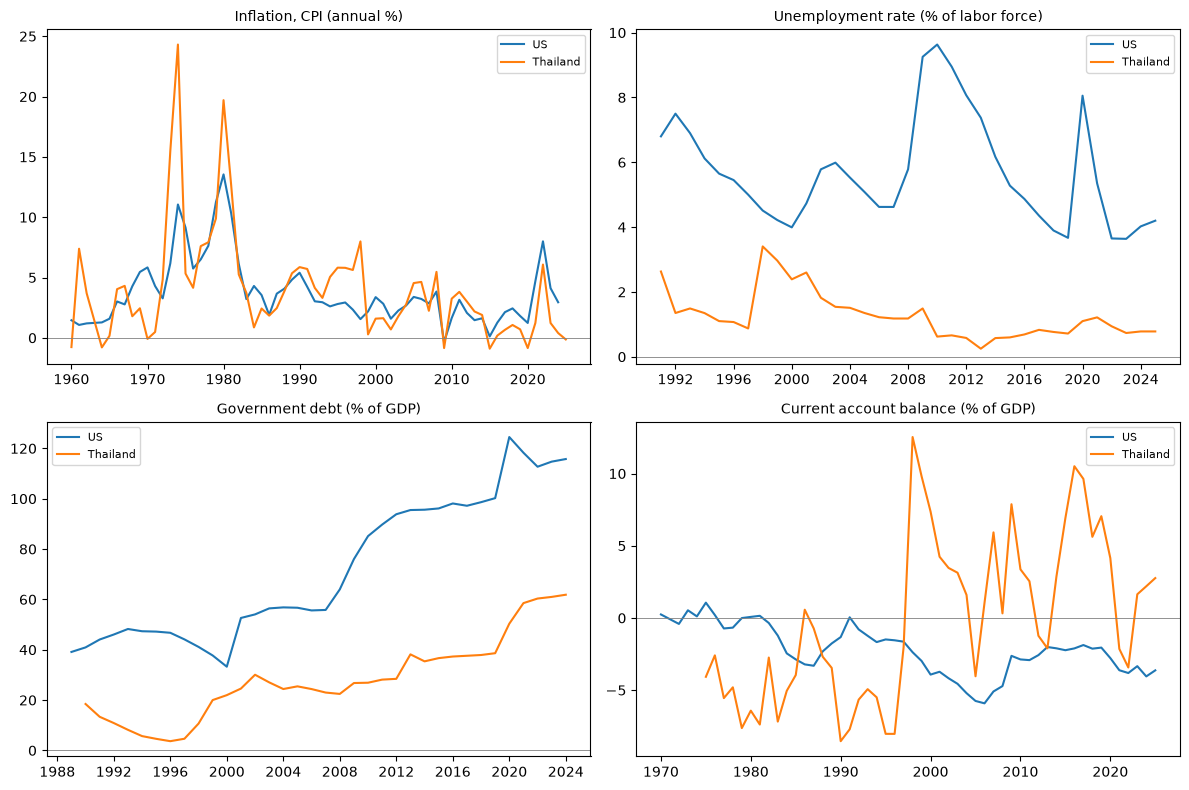

In [6]:
panels = {
    "Inflation, CPI (annual %)": ("us_inflation", "th_inflation"),
    "Unemployment rate (% of labor force)": ("us_unemployment", "th_unemployment"),
    "Government debt (% of GDP)": ("us_gov_debt_gdp", "th_gov_debt_gdp"),
    "Current account balance (% of GDP)": ("us_current_account_gdp", "th_current_account_gdp"),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (title, (us_id, th_id)) in zip(axes.flat, panels.items()):
    us_series = load(us_id)["value"]
    th_series = load(th_id)["value"]
    ax.plot(us_series.index, us_series, label="US")
    ax.plot(th_series.index, th_series, label="Thailand")
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color="grey", linewidth=0.6)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
latest = {}
for title, (us_id, th_id) in panels.items():
    us_series, th_series = load(us_id)["value"], load(th_id)["value"]
    latest[title] = {
        "US": us_series.iloc[-1],
        "US (as of)": us_series.index[-1].date(),
        "Thailand": th_series.iloc[-1],
        "Thailand (as of)": th_series.index[-1].date(),
    }

pd.DataFrame(latest).T

,US,US (as of),Thailand,Thailand (as of)
"Inflation, CPI (annual %)",2.949525,2024-01-01,-0.133634,2025-01-01
Unemployment rate (% of labor force),4.198,2025-01-01,0.781,2025-01-01
Government debt (% of GDP),115.768353,2024-01-01,61.861416,2024-01-01
Current account balance (% of GDP),-3.626987,2025-01-01,2.7629,2025-01-01


## 4. FRED series (optional)

`us_cpi` (monthly CPI, more granular than the World Bank's annual inflation figure) and `fed_funds_rate` (the policy rate that anchors the short end of the yield curve) need `FRED_API_KEY` in `.env`. If it's not configured, these fail gracefully — same as every other keyed series in this package — without affecting anything above.

In [8]:
fred_results = update("fred")
pd.Series(fred_results, name="status").to_frame()

series us_cpi failed: environment variable FRED_API_KEY is not set (put it in a .env file, see .env.example)


series fed_funds_rate failed: environment variable FRED_API_KEY is not set (put it in a .env file, see .env.example)


,status
us_cpi,failed: environment variable FRED_API_KEY is n...
fed_funds_rate,failed: environment variable FRED_API_KEY is n...


In [9]:
if fred_results.get("fed_funds_rate", "").startswith("updated") or fred_results.get("fed_funds_rate") == "up-to-date":
    fed_funds = load("fed_funds_rate")
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(us_3m.index, us_3m["value"], label="3-month T-bill yield")
    ax.plot(fed_funds.index, fed_funds["value"], label="Fed funds effective rate")
    ax.set_title("Fed funds rate vs. short-end Treasury yield")
    ax.set_ylabel("%")
    ax.legend()
    plt.show()
else:
    print("fed_funds_rate unavailable (FRED_API_KEY not configured) — skipping this comparison.")

fed_funds_rate unavailable (FRED_API_KEY not configured) — skipping this comparison.
